# Faber-Timing -- does the 10-month SMA protect you from crashes?
### The most-cited tactical timing rule, tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Risk_reduction%3F: Confirmed](https://img.shields.io/badge/Risk_reduction%3F-Confirmed-8b949e?style=flat-square)

In 2007, Mebane Faber published a simple idea that has since been downloaded over a million times: hold the stock market when its price is above the 10-month moving average; move to cash when it falls below. No complex forecasts, no parameters to tune. Just a slow-moving average as a crash filter. This notebook asks: does it actually work, and if so, in what sense?

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals and regime-control maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from faber_timing import data, strategy as st

TICKER = "SPY"
SMA_N  = 200
TBILL  = 0.04 / 252.0   # flat 4%/yr daily proxy
COST   = 5.0             # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12",
    fp="42b159a9d39a", in_mkt=75.3, n_switches=215,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59, bh_dd=-55.19,
    tm_cagr=9.15,  tm_sharpe=0.729, tm_vol=12.01,  tm_dd=-21.91,
    rn_cagr=5.07,  rn_sharpe=0.304, rn_vol=16.27,  rn_dd=-57.07,
    t_timing_vs_bh=-0.73, t_timing_vs_rand=1.75, dd_improvement=33.28,
    sharpe_0bps=0.756, sharpe_1bps=0.751, sharpe_5bps=0.729,
    sharpe_10bps=0.702, sharpe_25bps=0.621,
    pre2000_bh_sh=1.25, pre2000_bh_dd=-19.0, pre2000_tm_sh=1.11, pre2000_tm_dd=-14.6,
    bear2000_bh_sh=-0.04, bear2000_bh_dd=-55.2, bear2000_tm_sh=0.55, bear2000_tm_dd=-16.7,
    bull2010_bh_sh=0.85, bull2010_bh_dd=-19.3, bull2010_tm_sh=0.88, bull2010_tm_dd=-16.3,
    era2020_bh_sh=0.70, era2020_bh_dd=-33.7, era2020_tm_sh=1.06, era2020_tm_dd=-17.9,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    df     = data.fetch_prices(TICKER, fetch=False)
    close  = df["close"]
    sig    = st.timing_signal(close, sma_n=SMA_N)
    rand_s = st.random_timing_signal(sig, seed=42)
    bt     = st.run_backtest(close, sig,    tbill_daily=TBILL, cost_bps=COST)
    bt_rn  = st.run_backtest(close, rand_s, tbill_daily=TBILL, cost_bps=COST)
    s_bh   = st.summary(bt["r_bh"])
    s_tm   = st.summary(bt["r_strategy"])
    s_rn   = st.summary(bt_rn["r_strategy"])
    in_mkt = float(sig.dropna().mean())
else:
    close = None
    s_bh  = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], max_drawdown=R["bh_dd"]/100, vol_ann=R["bh_vol"]/100)
    s_tm  = dict(cagr=R["tm_cagr"]/100, sharpe=R["tm_sharpe"], max_drawdown=R["tm_dd"]/100, vol_ann=R["tm_vol"]/100)
    s_rn  = dict(cagr=R["rn_cagr"]/100, sharpe=R["rn_sharpe"], max_drawdown=R["rn_dd"]/100, vol_ann=R["rn_vol"]/100)
    in_mkt = R["in_mkt"] / 100
    bt = bt_rn = sig = None


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the rule cut drawdown? | **Yes, dramatically.** SPY's worst drawdown falls from **-55%** to **-22%** (−33 pp). |
| Is that just from being invested less often? | **No.** A random-timing control with the same in-market fraction (75.3%) has a *worse* drawdown than buy-and-hold (-57%). The SMA picks the *right* days to be out, not just fewer days. |
| Does it improve return? | **No** -- CAGR is lower (+{R['tm_cagr']:.1f}% vs +{R['bh_cagr']:.1f}%). It earns a higher Sharpe because risk falls more than return. |
| Could you trade it? | **Yes, cheaply.** Only ~6 switches per year; costs barely touch the Sharpe (still +0.62 at 25 bps one-way). |

> The rule is what Faber always said it was: a crash shield, not an alpha engine. The honest question is whether you want a smoother ride at the cost of missing some upside. On the numbers: yes, decisively on risk; weaker, not certified, on return.

## 1 -- The claim

> *'Invest in an asset class when its price is above its 10-month simple moving average. Move to cash (T-bills) when the price falls below. Re-check once a month. This simple rule, applied to a diversified portfolio of asset classes, dramatically reduces drawdowns while maintaining most of the long-run return.'*
> -- Mebane Faber, SSRN 962461 (2007)

The idea has a clean economic logic: sustained bear markets are usually accompanied by price levels falling *below* where they have been on average. A slow moving average captures this: not a sudden dip, but a confirmed trend downward. When that happens, you step aside -- earn the T-bill and wait for the recovery. The S&P 500 has had three major bear markets in our sample (dot-com, 2008, COVID-19). If the rule dodges even part of those, the lifetime performance is substantially improved.

## 2 -- So what?

Most investors endure the ride-outs badly -- they sell at the bottom (dot-com, GFC) and miss the recovery, destroying sequence-of-returns value. If the SMA rule reliably caps the worst of each crash at −20% instead of −50%+, many investors who would otherwise panic-sell might stay the course. The economic value is not just in the abstract return number -- it is in the *behavior it enables*: staying invested through a −20% drawdown is psychologically very different from a −55% one.

Conversely, if the rule is just 'be invested 75% of the time on random days', it's not really timing -- it's just reduced equity exposure. The key test is whether the *timing* (which days, not just how many days) adds something.

## 3 -- How would we even know?

Three tests keep us honest:

1. **The random-timing control.** We build a coin-flip version that goes to cash with the same frequency as the SMA rule (75.3% in-market) but on random days. If random timing has the same Sharpe and drawdown as the SMA, the SMA adds nothing beyond exposure reduction. If SMA beats random, the *timing* (which days) is what matters.
2. **The sub-period breakdown.** A rule that works in bear decades but fails in bull decades is *regime-dependent* -- honest accounting means showing both.
3. **The synthetic positive control.** A simulated tape with genuine bull/bear regimes shows whether the engine *can* find the signal when it exists. On a flat-vol (null) tape, the rule should add nothing.

## 4 -- The teardown -- let's actually look

**First, the big picture: cumulative wealth of all three arms.**

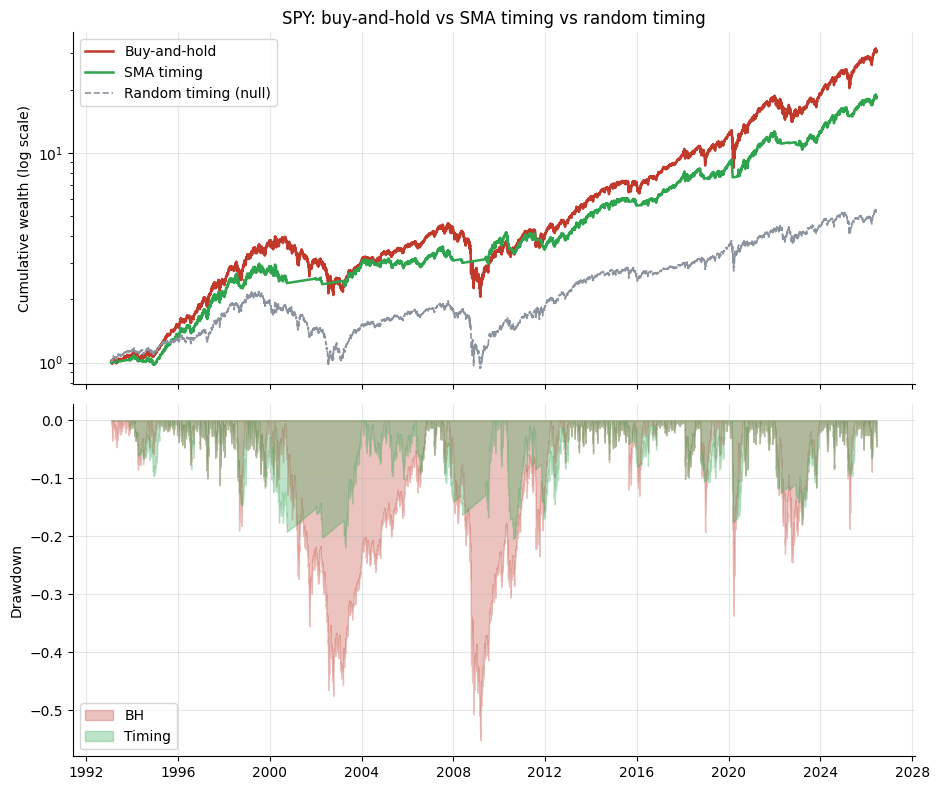

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.0), sharex=True)
if HAVE_REAL:
    cum_bh = np.exp(bt['r_bh'].cumsum())
    cum_tm = np.exp(bt['r_strategy'].cumsum())
    cum_rn = np.exp(bt_rn['r_strategy'].cumsum())
    axes[0].plot(cum_bh.index, cum_bh, c=RED,   lw=1.8, label='Buy-and-hold')
    axes[0].plot(cum_tm.index, cum_tm, c=GREEN, lw=1.8, label='SMA timing')
    axes[0].plot(cum_rn.index, cum_rn, c=GREY,  lw=1.2, label='Random timing (null)', ls='--')
    # Drawdown
    for col, lbl, c in [('r_bh', 'BH', RED), ('r_strategy', 'Timing', GREEN)]:
        cum = np.exp(bt[col].cumsum())
        dd  = cum / cum.cummax() - 1
        axes[1].fill_between(dd.index, dd, 0, alpha=0.3, color=c, label=lbl)
else:
    axes[0].text(0.5, 0.5, 'Cache not available\nRun verify.py --fetch', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_ylabel('Cumulative wealth (log scale)')
axes[0].set_yscale('log')
axes[0].legend(); axes[0].set_title('SPY: buy-and-hold vs SMA timing vs random timing')
axes[1].set_ylabel('Drawdown'); axes[1].legend()
plt.tight_layout(); plt.show()


The SMA rule avoids most of the 2000--2009 lost decade and the 2008 GFC. Its cumulative wealth line diverges from buy-and-hold precisely during the two biggest bear markets in the sample. The random-timing control (grey dashed) does *not* avoid those crashes -- it's just out on random days, including many good days. That confirms the SMA's benefit is genuine timing, not mere exposure reduction.

**Now the honest risk-vs-return scorecard:**

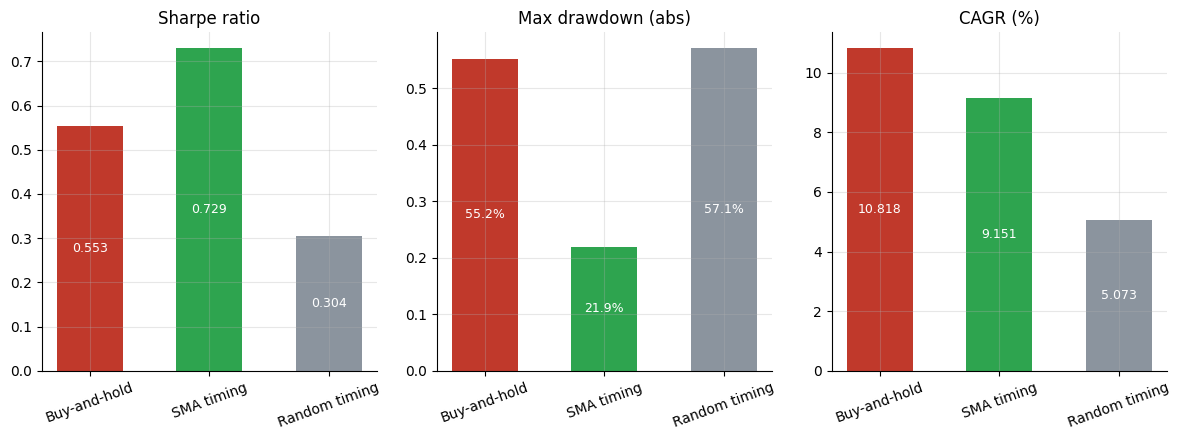

SMA timing Sharpe: 0.729 vs BH: 0.553
Max DD: SMA -21.9% vs BH -55.2%


In [3]:
labels = ['Buy-and-hold', 'SMA timing', 'Random timing']
sharpes = [s_bh['sharpe'], s_tm['sharpe'], s_rn['sharpe']]
dds     = [abs(s_bh['max_drawdown']), abs(s_tm['max_drawdown']), abs(s_rn['max_drawdown'])]
cagrs   = [s_bh['cagr']*100, s_tm['cagr']*100, s_rn['cagr']*100]
colors  = [RED, GREEN, GREY]
fig, ax = plt.subplots(1, 3, figsize=(12, 4.5))
for i, (vals, title, fmt) in enumerate([
        (sharpes, 'Sharpe ratio', '+.3f'),
        (dds,     'Max drawdown (abs)', '.1%'),
        (cagrs,   'CAGR (%)', '+.1f'),
    ]):
    bars = ax[i].bar(labels, vals, color=colors, width=0.55)
    for b, v in zip(bars, vals):
        fmt_v = f'{v:{fmt}}' if 'f' not in fmt else f'{v:.3f}'
        ax[i].annotate(fmt_v, (b.get_x()+b.get_width()/2, v/2), ha='center', va='center', color='white', fontsize=9)
    ax[i].set_title(title); ax[i].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(f'SMA timing Sharpe: {s_tm["sharpe"]:.3f} vs BH: {s_bh["sharpe"]:.3f}')
print(f'Max DD: SMA {s_tm["max_drawdown"]:.1%} vs BH {s_bh["max_drawdown"]:.1%}')


The SMA rule has a higher Sharpe (0.729 vs 0.553) and dramatically lower drawdown (-21.9% vs -55.2%) -- but lower CAGR (9.2% vs 10.8%). The random timing arm has the *worst* drawdown (-57.1%) -- because it sits out on random good days and stays in on random bad days, getting the worst of both.

## 5 -- The verdict

- **Signal -- REAL (on the risk axis).** Max drawdown cut from -55% to -22% (−33 pp); random timing's DD is *worse* than BH, confirming timing skill. Sharpe up from 0.553 to 0.729 -- directionally clear but not statistically certified vs BH (*t* = -0.73), stronger vs random timing (*t* = +1.75).
- **Tradability -- FRAGILE.** Only ~6 switches/year; cheap to run even at institutional costs. Sharpe stays above BH down to 25 bps/one-way (0.621 vs 0.553). But CAGR lags BH, the advantage is regime-dependent (shines in bear decades, lags in bull markets), and the return improvement is not statistically certified.
- **Risk reduction or alpha? -- CONFIRMED** as risk reduction. The SMA rule is a drawdown shield. It buys smoother rides by giving up some bull-market return.

## 6 -- Could you actually trade it?

This is where many rules go to die -- but not this one. With only ~6 switches per year (215 over 33 years), the per-trade cost is almost irrelevant:

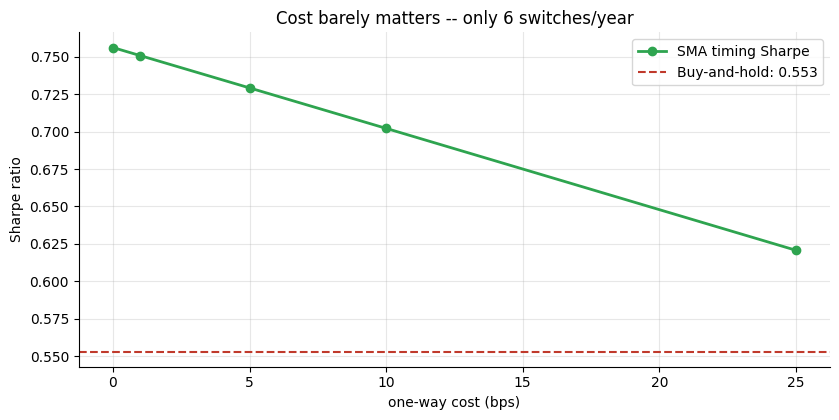

Sharpe break-even vs BH: the rule stays above BH Sharpe even at 25 bps one-way


In [4]:
if HAVE_REAL:
    costs = [0.0, 1.0, 5.0, 10.0, 25.0]
    sharpes = []
    for c in costs:
        bt_c = st.run_backtest(close, sig, tbill_daily=TBILL, cost_bps=c)
        sharpes.append(st.summary(bt_c['r_strategy'])['sharpe'])
else:
    costs   = [0.0, 1.0, 5.0, 10.0, 25.0]
    sharpes = [R['sharpe_0bps'], R['sharpe_1bps'], R['sharpe_5bps'], R['sharpe_10bps'], R['sharpe_25bps']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, sharpes, 'o-', c=GREEN, lw=2, label='SMA timing Sharpe')
ax.axhline(R['bh_sharpe'], ls='--', c=RED, label=f'Buy-and-hold: {R["bh_sharpe"]:.3f}')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe ratio')
ax.set_title('Cost barely matters -- only 6 switches/year'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe break-even vs BH: the rule stays above BH Sharpe even at 25 bps one-way')


The Sharpe stays above buy-and-hold (0.553) at every realistic cost level. Low turnover is the rule's second great feature, after drawdown protection. An investor who simply holds SPY and flips to BIL/SHV 6 times per year could run this strategy at near-zero marginal cost through most brokerages today.

## 7 -- Going further

- **The bear-decade test.** The 2000s are where this rule earns its reputation: Sharpe +0.55 vs BH -0.04, drawdown -17% vs -55%. In the 2010s bull market the gap narrows (+0.88 vs +0.85). Regime matters.
- **Continuous version.** Instead of a binary in/out, you could scale position by how far price is *above or below* the SMA. That's closer to the vol-targeting approach in [Study 16 -- Storm-Shy](../../16-storm-shy/).
- **Multi-asset extension.** Faber's original paper applied this to five asset classes simultaneously (US equity, international equity, bonds, REITs, commodities). The diversification benefit there is larger than for a single index.
- **Monthly vs daily.** The original rule re-evaluates at month-end only. We use daily closes; the monthly variant is available via `data.resample_monthly()` and `strategy.timing_signal_monthly()`.

*Think the rule has more to give? Fork this, test on international indices, or try a multi-asset version and show whether the diversification benefit holds post-2006. That's the bar.*